<a href="https://colab.research.google.com/github/holehouse-lab/soursop/blob/master/ped-resources/ped_ensemble_characterisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Biophysical characterisation of a PED ensemble

This notebook takes any ensemble from the [Protein Ensemble Database (PED)](https://proteinensemble.org), chosen by its identifier, and runs a standard set of analyses on it with [SOURSOP](https://soursop.readthedocs.io). Each analysis is set against polymer reference models built for the same chain length with [afrc](https://github.com/idptools/afrc):

1. **Radius of gyration**: the mean and distribution, against length-matched self-avoiding walks with scaling exponents ν = 0.33 (collapsed), 0.5 (ideal chain) and 0.589 (expanded, good solvent).
2. **End-to-end distance**: the same comparison.
3. **Helicity**: per-residue fractional helicity from DSSP, and how it is spread across the ensemble.
4. **Distance map**: the mean distance between every pair of residues.
5. **Scaling map**: the distance map divided by the Analytical Flory Random Coil (AFRC), showing which regions are more expanded or more compact than a random coil of the same sequence.
6. **Shape**: radius of gyration against asphericity for every conformer, over the AFRC's distribution.

**To use it:** set `PED_ID` below, then choose *Runtime → Run all*. The whole notebook takes a minute or two, most of it installing SOURSOP and afrc.

## Install SOURSOP and afrc

Colab comes with neither, so this cell installs both. If you are running the notebook somewhere they are already installed, skip it.

In [ ]:
# This uses uv, which is much faster than pip (and is itself installed first if
# it is missing); --system installs into Colab's own Python. SOURSOP's PED
# module is new in 2.0.8 and afrc's ensemble building is new in 0.5.0; until
# those versions are on PyPI, they are installed from GitHub instead.
!command -v uv >/dev/null || pip install -q uv
!uv pip install --system -q "soursop>=2.0.8" 2>/dev/null || uv pip install --system -q "git+https://github.com/holehouse-lab/soursop.git"
!uv pip install --system -q "afrc>=0.5.0" 2>/dev/null || uv pip install --system -q "git+https://github.com/idptools/afrc.git@ensemble"

## Choose an ensemble

`PED_ID` can be a full ensemble identifier (`PED00184e001`), or an entry (`PED00184`) if that entry holds a single ensemble. To find identifiers, search [PED](https://proteinensemble.org) or use `ped.search()` (see the [PED examples](https://github.com/holehouse-lab/soursop/tree/master/demo_examples/ped_examples)).

The default is an NMR (RDC)-refined ensemble of the nuclear receptor interaction domain of Tif2 (500 conformers, 154 residues).

In [2]:
PED_ID = "PED00184e001"  # @param {type:"string"}

# Conformations in the AFRC reference ensemble (large, so its distributions are
# smooth) and in each of the SAW-nu reference ensembles
N_AFRC = 50000  # @param {type:"integer"}
N_SAW = 20000  # @param {type:"integer"}

# Save every figure as an editable PDF (downloadable at the end)
SAVE_FIGURES = False  # @param {type:"boolean"}

In [3]:
import os
import shutil

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter
from scipy.stats import gaussian_kde

from soursop import ped
from soursop.ssexceptions import SSException
from soursop.sstrajectory import SSTrajectory
from afrc import AnalyticalFRC
from afrc.polymer_models.nudep_saw import NuDepSAW

# Figure style: Arial throughout, text kept editable in Illustrator, no grid
# lines, and the xmgrace colour order (black, red, blue, green, purple).
# Colab does not have Arial, so there figures fall back to Liberation Sans
# (metrically identical to Arial) or matplotlib's default, DejaVu Sans
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "axes.grid": False,
    "axes.prop_cycle": plt.cycler(color=["black", "red", "blue", "green", "purple"]),
})

# SAW-nu reference models: scaling exponents, their colours, and the size scale
# (the root-mean-square distance between residues k apart is SAW_PREFACTOR * k**nu)
SAW_NUS = (0.33, 0.5, 0.589)
SAW_COLOURS = {0.33: "red", 0.5: "blue", 0.589: "green"}
SAW_PREFACTOR = 5.5  # Angstroms

MIN_SEPARATION = 10  # residue pairs closer than this in sequence are left out of the scaling map
N_BOOTSTRAP = 100  # resampled ensembles used to show the spread in per-residue helicity
SEED = 1  # makes the reference ensembles and the resampling reproducible

CACHE = "ped_cache"  # downloaded PED ensembles
MODEL_DIR = "reference_ensembles"  # AFRC and SAW-nu ensembles
FIGURE_DIR = "figures"


def finish(fig, name):
    """Show a figure, and also save it as a PDF if SAVE_FIGURES is set.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        The figure to show.
    name : str
        Short name for the figure; the PDF is saved as
        ``figures/<PED_ID>_<name>.pdf``.
    """
    if SAVE_FIGURES:
        os.makedirs(FIGURE_DIR, exist_ok=True)
        fig.savefig(os.path.join(FIGURE_DIR, f"{PED_ID}_{name}.pdf"))
    plt.show()

## Load the ensemble

The ensemble is downloaded from PED and read into SOURSOP, one frame per conformer. If PED holds weights for the conformers (from reweighting against experimental data), every average, histogram and map below uses them.

In [4]:
entry = ped.get_entry(PED_ID)
traj = ped.load_ensemble(PED_ID, cache_dir=CACHE)
protein = traj.proteinTrajectoryList[0]
if len(traj.proteinTrajectoryList) > 1:
    print(f"{PED_ID} has {len(traj.proteinTrajectoryList)} chains; analysing the first")

# per-conformer weights; None means every conformer counts equally (PED also
# serves uniform weights, which are treated as no weights)
weights = ped.get_ensemble_weights(PED_ID)
if weights is not None and np.allclose(weights, weights[0]):
    weights = None
soursop_weights = False if weights is None else weights  # SOURSOP's "unweighted" is False

# afrc needs the sequence. The AFRC only knows the 20 standard amino acids, so
# common variants and modified residues are mapped onto their parent residue
# (e.g. phosphoserine onto serine), and caps, which have no CA, are left out
ONE_LETTER = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C", "GLN": "Q", "GLU": "E",
    "GLY": "G", "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F",
    "PRO": "P", "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
    "HID": "H", "HIE": "H", "HIP": "H", "HSD": "H", "HSE": "H", "HSP": "H", "ASH": "D",
    "GLH": "E", "LYN": "K", "CYX": "C", "CYM": "C", "SEP": "S", "TPO": "T", "PTR": "Y",
    "MSE": "M",
}
names = protein.get_amino_acid_sequence(numbered=False)
unknown = sorted({names[i] for i in protein.resid_with_CA} - set(ONE_LETTER))
if unknown:
    raise ValueError(f"No one-letter code for residue(s) {unknown}: add them to ONE_LETTER")
sequence = "".join(ONE_LETTER[names[i]] for i in protein.resid_with_CA)
N = len(sequence)
residues = np.arange(1, N + 1)  # residue numbers used on every plot (1 to N)

# one point per conformer is drawn semi-transparent, more so for larger
# ensembles, so that overlapping points show where the conformers are densest
POINT_ALPHA = float(np.clip(60 / protein.n_frames, 0.12, 0.8))

# per-conformer global properties
rg = protein.get_radius_of_gyration()
re = protein.get_end_to_end_distance(mode="CA")
asphericity = protein.get_asphericity(verbose=False)

print(f"{PED_ID}: {entry.title}")
print(f"{protein.n_frames} conformers, {N} residues, {'weighted' if weights is not None else 'unweighted'}")
print(sequence)

PED00184e001: NMR RDC-refined ensemble of Tif2 NRID
500 conformers, 154 residues, unweighted
GPHMERADGQSRLHDSKGQTKLLQLLTTKSDQMEPSPLASSLSDTNKDSTGSLPGSGSTHGTSLKEKHKILHRLLQDSSSPVDLAKLTAEATGKDLSQESSSTAPGSEVTIKQEPVSPKKKENALLRYLLDKDDTKDIGLPEITPKLERLDSKT


## Build the reference ensembles

Both reference models are built with afrc for exactly this chain, saved as PDB/XTC files (one bead per residue), and read into SOURSOP to be analysed like any other ensemble.

* **Self-avoiding walks with a set scaling exponent (SAW-ν)** [1, 2]: ν = 0.33 is a collapsed globule, 0.5 an ideal chain and 0.589 a chain in good solvent. afrc builds these as a Gaussian approximation, which gets the size and scaling of every inter-residue distance right. The distances are Gaussian-distributed, though, and the radius of gyration comes out about 5% below that of a true self-avoiding walk.
* **The Analytical Flory Random Coil (AFRC)** [3]: an ideal chain (ν = 0.5) specific to this sequence, which describes how the chain would behave if chain-chain and chain-solvent interactions exactly cancelled out. Every inter-residue distance in an AFRC ensemble has exactly the AFRC's distribution. We build a large ensemble so that its distributions are smooth.

[1] Zheng, W. *et al.* (2018). Inferring properties of disordered chains from FRET transfer efficiencies. *J. Chem. Phys.* 148, 123329.
[2] Soranno, A. (2020). Physical basis of the disorder-order transition. *Arch. Biochem. Biophys.* 685, 108305.
[3] Alston, J. J., Ginell, G. M., Soranno, A. & Holehouse, A. S. (2023). The analytical Flory random coil is a simple-to-use reference model for unfolded and disordered proteins. *J. Phys. Chem. B* 127, 4746-4760.

In [5]:
os.makedirs(MODEL_DIR, exist_ok=True)


def build_and_load(model, name, n, **parameters):
    """Build a reference ensemble with afrc, save it, and read it into SOURSOP.

    Parameters
    ----------
    model : afrc model
        Any afrc model with a ``save_ensemble()`` method (e.g. ``AnalyticalFRC``
        or ``NuDepSAW``).
    name : str
        File name (without extension) for the PDB/XTC pair, written in
        ``MODEL_DIR``.
    n : int
        Number of conformations to build.
    **parameters
        Model parameters passed on to ``save_ensemble()`` (e.g. ``nu``).

    Returns
    -------
    soursop.ssprotein.SSProtein
        The reference ensemble, one frame per conformation.
    """
    path = os.path.join(MODEL_DIR, name)
    model.save_ensemble(path, n=n, seed=SEED, **parameters)
    return SSTrajectory(path + ".xtc", path + ".pdb").proteinTrajectoryList[0]


# SAW-nu: one ensemble per scaling exponent (only Rg is needed from these; the
# end-to-end distance distribution is known analytically)
saw = NuDepSAW(sequence)
saw_rg = {}
for nu in SAW_NUS:
    model = build_and_load(saw, f"saw_nu_{nu}".replace(".", "_"), N_SAW, nu=nu, prefactor=SAW_PREFACTOR)
    saw_rg[nu] = model.get_radius_of_gyration()

# AFRC: one large ensemble
afrc = AnalyticalFRC(sequence)
afrc_protein = build_and_load(afrc, "afrc", N_AFRC)
afrc_rg = afrc_protein.get_radius_of_gyration()
afrc_asphericity = afrc_protein.get_asphericity(verbose=False)

print(f"Built {len(SAW_NUS)} SAW-nu ensembles of {N_SAW:,} conformations and an AFRC ensemble of {N_AFRC:,}")

Built 3 SAW-nu ensembles of 20,000 conformations and an AFRC ensemble of 50,000


## 1. Radius of gyration

The black histogram is the PED ensemble. The coloured lines are length-matched SAW-ν ensembles, and the triangles along the top mark the means.

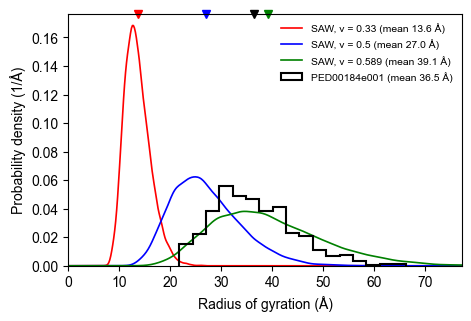

In [6]:
def mark_mean(ax, value, colour):
    """Mark a mean with a triangle along the top of an axis.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axis to mark.
    value : float
        The mean (in data units along x).
    colour : str
        Colour of the marker.
    """
    ax.plot(value, 1.0, "v", color=colour, ms=6, transform=ax.get_xaxis_transform(), clip_on=False)


rg_mean = np.average(rg, weights=weights)
upper = 1.05 * max(rg.max(), np.percentile(saw_rg[max(SAW_NUS)], 99.5))

fig, ax = plt.subplots(figsize=(4.6, 3.1), constrained_layout=True)
grid = np.linspace(0, upper, 400)
for nu in SAW_NUS:
    # a kernel density estimate gives a smooth curve from the sampled ensemble
    ax.plot(grid, gaussian_kde(saw_rg[nu])(grid), color=SAW_COLOURS[nu], lw=1.2,
            label=f"SAW, ν = {nu} (mean {saw_rg[nu].mean():.1f} Å)")
    mark_mean(ax, saw_rg[nu].mean(), SAW_COLOURS[nu])
ax.hist(rg, bins=np.histogram_bin_edges(rg, bins="auto"), weights=weights, density=True,
        histtype="step", color="black", lw=1.5, label=f"{PED_ID} (mean {rg_mean:.1f} Å)")
mark_mean(ax, rg_mean, "black")
ax.set_xlim(0, upper)
ax.set_ylim(bottom=0)
ax.set_xlabel("Radius of gyration (Å)")
ax.set_ylabel("Probability density (1/Å)")
ax.legend(frameon=False, fontsize=7.5)
finish(fig, "rg")

## 2. End-to-end distance

The distance between the Cα atoms of the first and last residues. For SAW-ν the end-to-end distribution is known analytically, so these lines are exact rather than built from an ensemble.

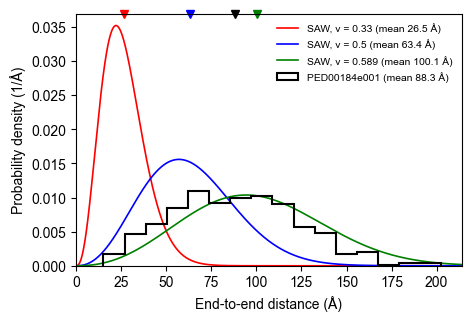

In [7]:
re_mean = np.average(re, weights=weights)
saw_re = {nu: saw.get_end_to_end_distribution(nu=nu, prefactor=SAW_PREFACTOR) for nu in SAW_NUS}
r, p = saw_re[max(SAW_NUS)]
upper = 1.05 * max(re.max(), r[np.searchsorted(np.cumsum(p), 0.995)])  # 99.5th percentile of the most expanded model

fig, ax = plt.subplots(figsize=(4.6, 3.1), constrained_layout=True)
for nu, (r, p) in saw_re.items():
    # p is a probability per grid point, so divide by the grid spacing for a density
    mean = np.sum(r * p)
    ax.plot(r, p / (r[1] - r[0]), color=SAW_COLOURS[nu], lw=1.2, label=f"SAW, ν = {nu} (mean {mean:.1f} Å)")
    mark_mean(ax, mean, SAW_COLOURS[nu])
ax.hist(re, bins=np.histogram_bin_edges(re, bins="auto"), weights=weights, density=True,
        histtype="step", color="black", lw=1.5, label=f"{PED_ID} (mean {re_mean:.1f} Å)")
mark_mean(ax, re_mean, "black")
ax.set_xlim(0, upper)
ax.set_ylim(bottom=0)
ax.set_xlabel("End-to-end distance (Å)")
ax.set_ylabel("Probability density (1/Å)")
ax.legend(frameon=False, fontsize=7.5)
finish(fig, "re")

## 3. Helicity

DSSP classifies every residue in every conformer as helical or not.

* **Left:** the fraction of conformers in which each residue is helical (black line). The red points show how much that profile moves between ensembles resampled from this one (`N_BOOTSTRAP` bootstrap resamples; one point per resample), i.e. how well a finite ensemble pins down each residue's helicity.
* **Right:** the fraction of residues that are helical in each conformer (one point per conformer; the black bar is the mean). A tight cloud means the helicity is spread evenly across the ensemble, and a long tail means a few conformers hold most of it.

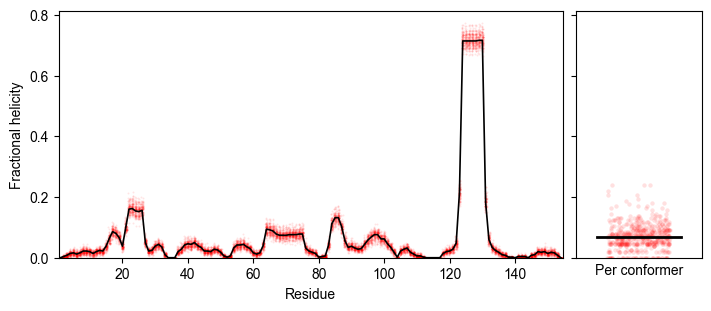

Mean helicity 0.070; most helical residue 129 (L), 0.72


In [8]:
try:
    _, helix, _, _ = protein.get_secondary_structure_DSSP(return_per_frame=True)
except SSException as error:
    # e.g. a C-alpha-only ensemble, which has no backbone for DSSP
    helix = None
    print(f"Skipping helicity: DSSP needs a full backbone ({error})")

if helix is not None:
    rng = np.random.default_rng(SEED)
    profile = np.average(helix, axis=0, weights=weights)
    per_conformer = helix.mean(axis=1)
    # each bootstrap resample, drawn with the conformer weights, is summarised by how
    # many times it picked each conformer; its helicity profile is then one matrix product
    picks = rng.multinomial(protein.n_frames, np.full(protein.n_frames, 1 / protein.n_frames) if weights is None else weights, size=N_BOOTSTRAP)
    bootstrap = picks @ helix / protein.n_frames  # (N_BOOTSTRAP, N)
    top = max(0.05, 1.05 * max(bootstrap.max(), per_conformer.max()))

    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(7.0, 3.0), sharey=True, constrained_layout=True,
                                  gridspec_kw={"width_ratios": [4, 1]})
    jitter = rng.uniform(-0.3, 0.3, size=bootstrap.shape)
    ax.scatter(residues + jitter, bootstrap, s=2, color="red", alpha=0.1, lw=0, rasterized=True)
    ax.plot(residues, profile, color="black", lw=1.2)
    ax.set_xlim(0.5, N + 0.5)
    ax.set_ylim(0, top)
    ax.set_xlabel("Residue")
    ax.set_ylabel("Fractional helicity")

    ax2.scatter(rng.uniform(-0.3, 0.3, size=per_conformer.size), per_conformer, s=10, color="red",
                alpha=POINT_ALPHA, lw=0)
    ax2.plot([-0.4, 0.4], [np.average(per_conformer, weights=weights)] * 2, color="black", lw=2)
    ax2.set_xlim(-0.6, 0.6)
    ax2.set_xticks([])
    ax2.set_xlabel("Per conformer")
    finish(fig, "helicity")

    print(f"Mean helicity {np.average(per_conformer, weights=weights):.3f}; most helical residue "
          f"{residues[np.argmax(profile)]} ({sequence[np.argmax(profile)]}), {profile.max():.2f}")

## 4. Distance map

The mean Cα-Cα distance between every pair of residues.

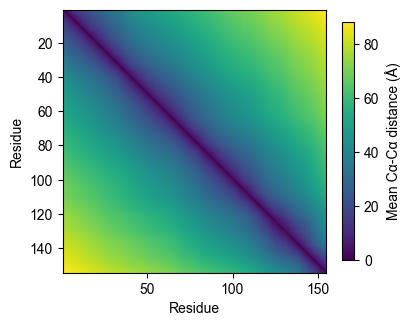

In [9]:
distance_map, _ = protein.get_distance_map(mode="CA", weights=soursop_weights, verbose=False)
distance_map = distance_map + distance_map.T  # SOURSOP returns the upper triangle; mirror it
extent = [0.5, N + 0.5, N + 0.5, 0.5]

fig, ax = plt.subplots(figsize=(4.0, 3.3), constrained_layout=True)
im = ax.imshow(distance_map, cmap="viridis", vmin=0, extent=extent)
ax.set_xlabel("Residue")
ax.set_ylabel("Residue")
fig.colorbar(im, ax=ax, shrink=0.85).set_label("Mean Cα-Cα distance (Å)")
finish(fig, "distance_map")

## 5. Scaling map (normalised by the AFRC)

Each mean inter-residue distance divided by the AFRC's prediction for the same pair of residues. Red pairs are further apart than in a random coil of this sequence (expanded), and blue pairs are closer together (compacted). Pairs fewer than `MIN_SEPARATION` residues apart in sequence are left out (grey), since at short range the AFRC's Gaussian chain is not a good model of the backbone.

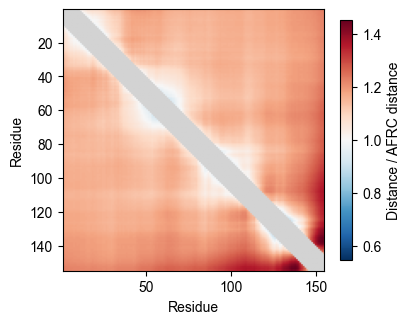

Across all pairs at least 10 residues apart, distances are on average 1.16 times the AFRC's (range 0.91 to 1.45)


In [10]:
afrc_map = afrc.get_distance_map(symmetric_map=True)
separation = np.abs(np.subtract.outer(residues, residues))
with np.errstate(divide="ignore", invalid="ignore"):
    ratio = np.where(separation >= MIN_SEPARATION, distance_map / afrc_map, np.nan)
limit = np.nanmax(np.abs(ratio - 1))

cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("lightgrey")
fig, ax = plt.subplots(figsize=(4.0, 3.3), constrained_layout=True)
im = ax.imshow(ratio, cmap=cmap, vmin=1 - limit, vmax=1 + limit, extent=extent)
ax.set_xlabel("Residue")
ax.set_ylabel("Residue")
fig.colorbar(im, ax=ax, shrink=0.85).set_label("Distance / AFRC distance")
finish(fig, "scaling_map")

print(f"Across all pairs at least {MIN_SEPARATION} residues apart, distances are on average "
      f"{np.nanmean(ratio):.2f} times the AFRC's (range {np.nanmin(ratio):.2f} to {np.nanmax(ratio):.2f})")

## 6. Shape: radius of gyration against asphericity

Each red point is one conformer of the PED ensemble, drawn semi-transparent so that denser regions look darker. The black contours enclose 25, 50, 75 and 95% of the AFRC ensemble. Asphericity is 0 for a sphere and 1 for a rod.

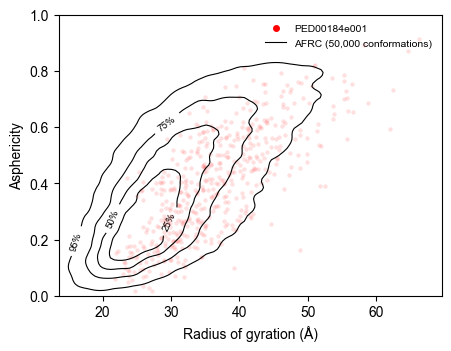

In [11]:
x_low = 0.9 * min(np.percentile(afrc_rg, 0.1), rg.min())
x_high = 1.05 * max(np.percentile(afrc_rg, 99.9), rg.max())

# density of the AFRC ensemble on a grid, smoothed a little
density, x_edges, y_edges = np.histogram2d(afrc_rg, afrc_asphericity, bins=100, range=[[x_low, x_high], [0, 1]])
density = gaussian_filter(density, 1.5)
x_centres = 0.5 * (x_edges[1:] + x_edges[:-1])
y_centres = 0.5 * (y_edges[1:] + y_edges[:-1])

# the density levels whose contours enclose each fraction of the conformations
enclosed = (0.95, 0.75, 0.5, 0.25)
ordered = np.sort(density.ravel())[::-1]
cumulative = np.cumsum(ordered) / ordered.sum()
levels = [ordered[np.searchsorted(cumulative, q)] for q in enclosed]  # increasing density

fig, ax = plt.subplots(figsize=(4.4, 3.4), constrained_layout=True)
contours = ax.contour(x_centres, y_centres, density.T, levels=levels, colors="black", linewidths=0.8)
ax.clabel(contours, fmt={level: f"{q:.0%}" for level, q in zip(levels, enclosed)}, fontsize=7)
ax.scatter(rg, asphericity, s=10, color="red", lw=0, alpha=POINT_ALPHA)
ax.set_xlim(x_low, x_high)
ax.set_ylim(0, 1)
ax.set_xlabel("Radius of gyration (Å)")
ax.set_ylabel("Asphericity")
ax.legend(handles=[
    Line2D([], [], marker="o", ls="", color="red", ms=4, label=PED_ID),
    Line2D([], [], color="black", lw=0.8, label=f"AFRC ({N_AFRC:,} conformations)"),
], frameon=False, fontsize=7.5, loc="upper right")
finish(fig, "rg_asphericity")

## Summary

In [12]:
afrc_re = afrc.get_mean_end_to_end_distance()
afrc_rg_mean = afrc.get_mean_radius_of_gyration()
summary = [
    ("Conformers", f"{protein.n_frames}", ""),
    ("Residues", f"{N}", ""),
    ("<Rg> (A)", f"{rg_mean:.1f}", f"{afrc_rg_mean:.1f}"),
    ("<Re> (A)", f"{re_mean:.1f}", f"{afrc_re:.1f}"),
    ("<Asphericity>", f"{np.average(asphericity, weights=weights):.3f}", f"{afrc_asphericity.mean():.3f}"),
]
if helix is not None:
    summary.append(("Mean helicity", f"{np.average(per_conformer, weights=weights):.3f}", ""))

print(f"{'':16s}{PED_ID:>14s}{'AFRC':>10s}")
for label, value, reference in summary:
    print(f"{label:16s}{value:>14s}{reference:>10s}")
print(f"\nRg / Rg(AFRC) = {rg_mean / afrc_rg_mean:.2f}, Re / Re(AFRC) = {re_mean / afrc_re:.2f} "
      "(above 1: more expanded than a random coil; below 1: more compact)")

                  PED00184e001      AFRC
Conformers                 500          
Residues                   154          
<Rg> (A)                  36.5      31.0
<Re> (A)                  88.3      72.2
<Asphericity>            0.401     0.394
Mean helicity            0.070          

Rg / Rg(AFRC) = 1.18, Re / Re(AFRC) = 1.22 (above 1: more expanded than a random coil; below 1: more compact)


## Download the figures

If `SAVE_FIGURES` is set, this zips the PDFs and, in Colab, downloads them.

In [13]:
if SAVE_FIGURES:
    archive = shutil.make_archive(f"{PED_ID}_figures", "zip", FIGURE_DIR)
    try:
        from google.colab import files
        files.download(archive)
    except ImportError:  # not running in Colab
        print(f"Figures saved in {FIGURE_DIR}/ and zipped into {archive}")
else:
    print("Set SAVE_FIGURES at the top and re-run to save the figures as PDFs")

Set SAVE_FIGURES at the top and re-run to save the figures as PDFs
